In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../../Datasets/uber.csv')

<h2 style="color:#FF5733"> 1- Overview</h2>

In [5]:
df.shape

(200000, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 23.4 MB


In [7]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [8]:
df.isnull().sum()
df.isnull().mean()*100

Unnamed: 0           0.0000
key                  0.0000
fare_amount          0.0000
pickup_datetime      0.0000
pickup_longitude     0.0000
pickup_latitude      0.0000
dropoff_longitude    0.0005
dropoff_latitude     0.0005
passenger_count      0.0000
dtype: float64

In [9]:
df.dropna(inplace=True) 

<div style="background-color: #f8f9fa; border-left: 4px solid #28a745; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #28a745;">Missing Values Removal:</h4>
    <p style="margin: 0; color: #333; line-height: 1.6;">
        Removed all rows containing missing (null/NaN) values directly from the dataset to ensure data completeness and prevent errors during model training.
        Removal was done instead of imputing becuase only small percentage of rows contained missing values, so removing them has negligible impact on the model.
    </p>
</div>

In [10]:
df.duplicated().sum()
#checking for duplicates. There is none

np.int64(0)

In [11]:
df.drop(columns=['Unnamed: 0'],inplace=True)

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Removing Redundant Index Column:</h4>
    <p style="margin: 0; color: #333; line-height: 1.6;">
        Dropped the redundant <code>Unnamed: 0</code> column, which was created as an extra index during file and holds no feature value.
    </p>
</div>

<h2 style="color:#FF5733"> 2- Univariate Analysis </h2>

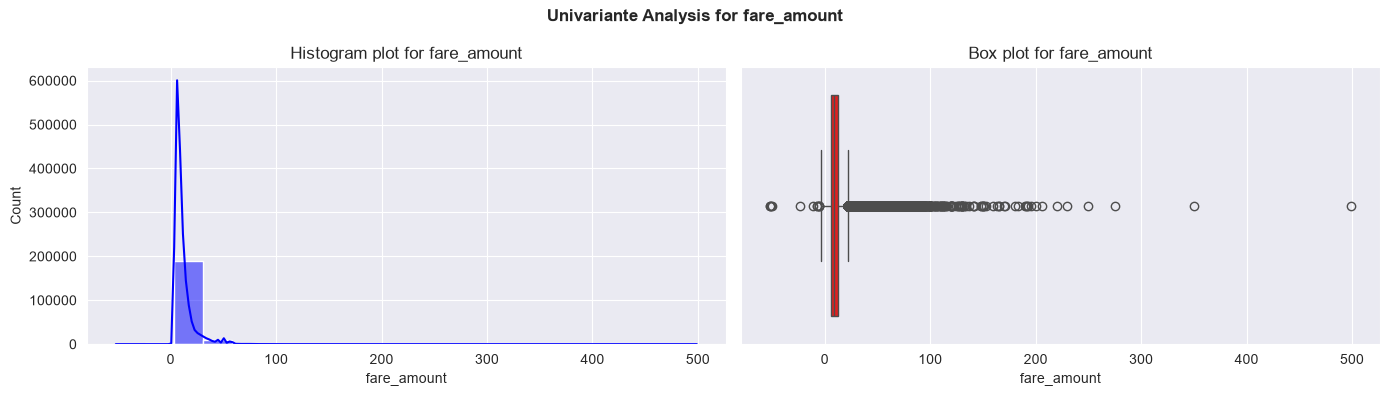

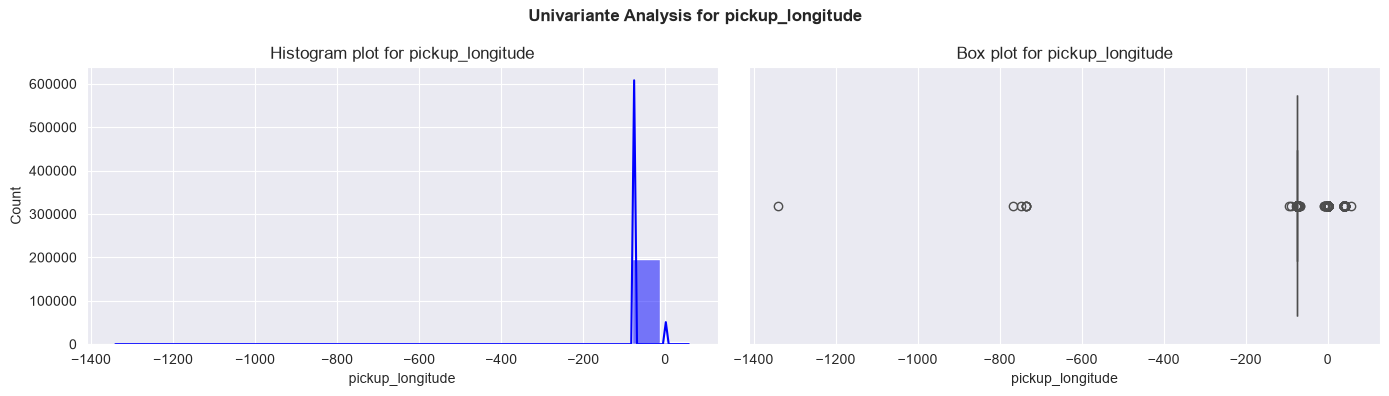

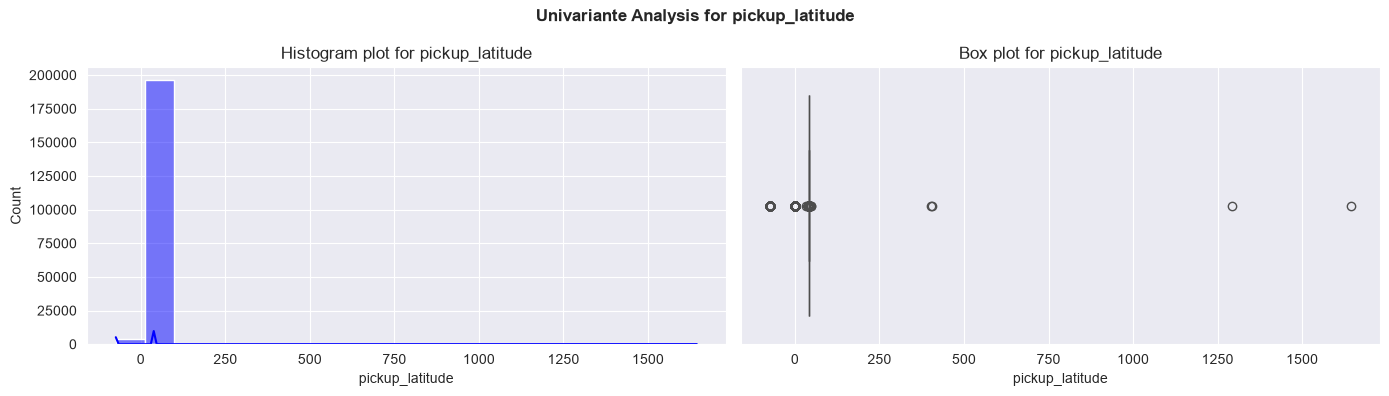

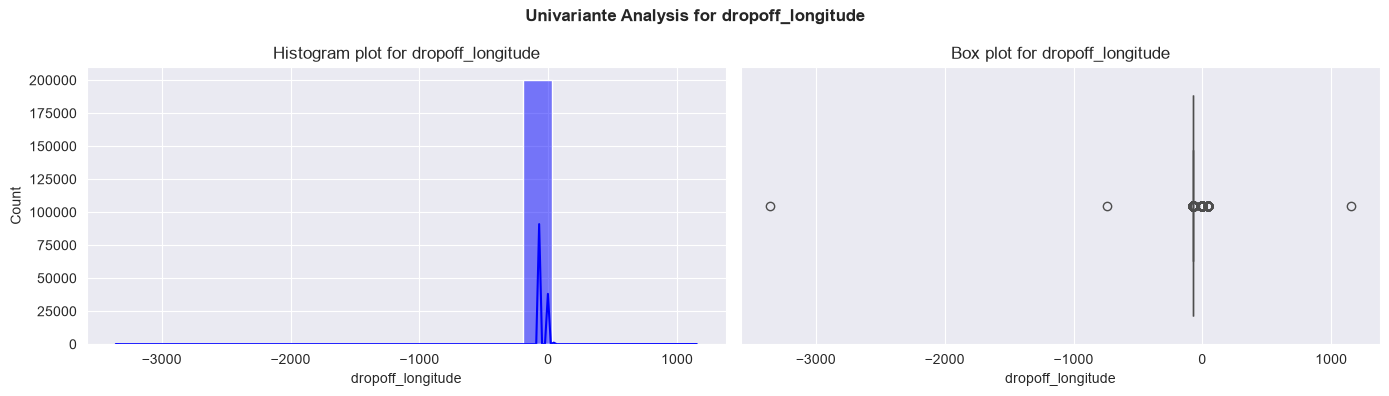

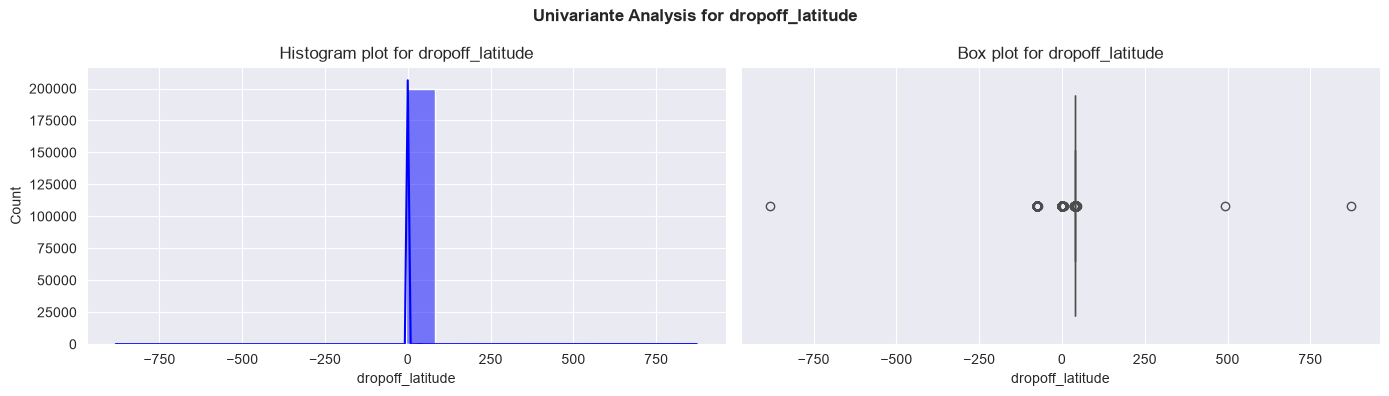

In [12]:
numerical_col = ['fare_amount','pickup_longitude',
                 'pickup_latitude','dropoff_longitude',
                 'dropoff_latitude']

for col in numerical_col:
    fig , axes = plt.subplots(1,2 , figsize=(14,4))
    fig.suptitle(f"Univariante Analysis for {col}",fontweight="bold")

    #Histogram plot
    sns.histplot(df[col], kde = True , ax = axes[0], bins=20 , color ="blue")
    axes[0].set_title(f"Histogram plot for {col}")

    # Box plot
    sns.boxplot(x=df[col], ax = axes[1] , color = "red")
    axes[1].set_title(f"Box plot for {col}")
    plt.tight_layout()
    plt.show()

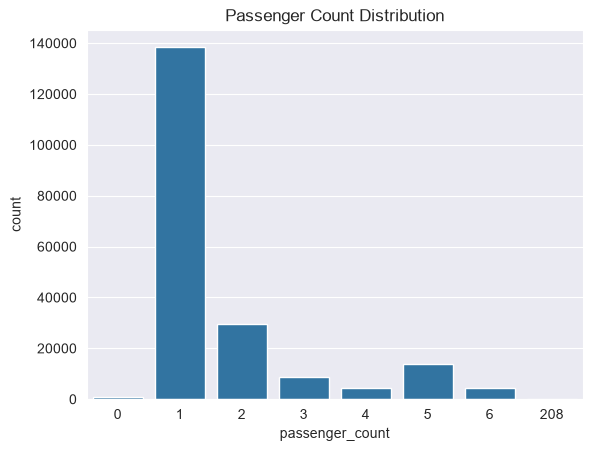

In [13]:
sns.countplot(x=df["passenger_count"])
plt.title("Passenger Count Distribution")
plt.show()

<h2 style="color:green"> Handling outliers </h2>

<h2 style="color:purple"> Fare Amount </h2>

In [14]:
print((df['fare_amount']>100).sum())

84


In [15]:
# Deleting negative , zero and extreme values in fare amount
df = df[(df['fare_amount']>2) & (df['fare_amount']<=100)]

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Fare Amount Cleaning Strategy:</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
        <li>Removed negative values and zeros because trip fares cannot be less than or equal to zero.</li>
        <li>Capped the maximum fare at 100 based on the histogram, where density drops to nearly zero.</li>
        <li>Only 84 rows (around 0.04% of the dataset) were above 100, so removing them is safe and won't affect the model.</li>
    </ul>
</div>

<h2 style="color:purple"> Longitude , latitude For pickup & drop off </h2>

In [16]:
df = df[(df['dropoff_longitude'].between(-75,-72))
        &(df['dropoff_latitude'].between(40,42))
        &(df['pickup_longitude'].between(-75,-72))
        &(df['pickup_latitude'].between(40,42))]

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Coordinates Cleaning Strategy:</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
        <li>Filtered coordinates using the official New York City bounding box (Longitude: [-75, -72], Latitude: [40, 42]).</li>
        <li>Removed invalid zero values (0.0) and extreme outliers caused by system errors.</li>
    </ul>
</div>

<h2 style="color:purple"> Passenger count </h2>

In [17]:
df = df[(df['passenger_count'].between(1,6))]

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Passenger Count Cleaning Strategy:</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
        <li>Filtered passenger counts to be within the realistic range of 1 to 6 passengers per trip.</li>
        <li>Removed invalid records with 0 passengers and extreme non-sensical values (e.g., negative or 200+ passengers).</li>
    </ul>
</div>

<h2 style="color:purple"> Key & Packup date time </h2>

In [18]:
print(df['key'].head())

0      2015-05-07 19:52:06.0000003
1      2009-07-17 20:04:56.0000002
2     2009-08-24 21:45:00.00000061
3      2009-06-26 08:22:21.0000001
4    2014-08-28 17:47:00.000000188
Name: key, dtype: str


In [19]:
print(df['pickup_datetime'].head())

0    2015-05-07 19:52:06 UTC
1    2009-07-17 20:04:56 UTC
2    2009-08-24 21:45:00 UTC
3    2009-06-26 08:22:21 UTC
4    2014-08-28 17:47:00 UTC
Name: pickup_datetime, dtype: str


<!-- Data Cleaning: key vs pickup_datetime -->
<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Feature Selection: key vs. pickup_datetime</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
        <li>Both columns provide the exact same date and time information for each trip.</li>
        <li><strong>Examples:</strong>
            <ul>
                <li><code>key</code>: <code>"2015-01-27 13:08:24.0000002"</code> (Contains extra random system ID digits).</li>
                <li><code>pickup_datetime</code>: <code>"2015-01-27 13:08:24 UTC"</code> (Clean standard timestamp).</li>
            </ul>
        </li>
        <li>The <code>key</code> column contains redundant random digits at the end, making <code>pickup_datetime</code> much cleaner and easier to parse.</li>
        <li><strong>Action:</strong> Dropped the <code>key</code> column to eliminate redundant data and retained <code>pickup_datetime</code> for feature extraction.</li>
    </ul>
</div>

In [20]:
df =df.drop(columns=['key'])

<h2 style="color:green"> Converting pickup datetime Datetime format </h2>

In [21]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

<div style="background-color: #f8f9fa; border-left: 4px solid #007bff; padding: 12px; margin: 10px 0; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #007bff;">Converting pickup_datetime to datetime format:</h4>
    <ul style="margin: 0; padding-left: 20px; color: #333; line-height: 1.6;">
       Converted pickup_datetime fron string format to datetime format. This enables extraction of useful features and temporal informations in the feature engineering process.
    </ul>
</div>

In [ ]:
df.to_csv("data_processed_uber.csv", index=False)